# Inspect ADE20k Segmentation Dataset

In [1]:
import os
root_dir = "datasets/ADEChallengeData2016/ADEChallengeData2016"
images_dir = os.path.join(root_dir, "images")
annotations_dir = os.path.join(root_dir, "annotations")

images_train_dir = os.path.join(images_dir, "training")
annotations_train_dir = os.path.join(annotations_dir, "training")
images_val_dir = os.path.join(images_dir, "validation")
annotations_val_dir = os.path.join(annotations_dir, "validation")

training_images = os.listdir(images_train_dir)
validation_images = os.listdir(images_val_dir)

print(len(training_images), len(validation_images))

20210 2000


In [2]:
import os
from pathlib import Path
from typing import Callable, Optional

from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import (
    Compose, Resize, ToTensor, Normalize, PILToTensor, InterpolationMode
)

class ADE20KSegDataset(Dataset):
    """
    images_dir: folder with RGB *.jpg files
    masks_dir : folder with 8-bit *.png masks (same filename stem)
    """

    def __init__(
        self,
        images_dir: str | Path,
        masks_dir: str | Path,
        img_transform : Optional[Callable] = None,
        mask_transform: Optional[Callable] = None,
    ):
        self.images_dir  = Path(images_dir)
        self.masks_dir   = Path(masks_dir)
        if img_transform is None:
            img_transform = Compose([
                Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
                ToTensor(),
                Normalize(mean=[0.485, 0.456, 0.406],
                          std =[0.229, 0.224, 0.225]),
            ])
        self.img_tf  = img_transform
        if mask_transform is None:
            mask_transform = Compose([
                Resize((256, 256), interpolation=InterpolationMode.NEAREST),
                PILToTensor(),  # keeps uint8 [0‒255]
            ])
        self.mask_tf = mask_transform

        self.image_files = sorted(p for p in self.images_dir.glob("*.jpg"))
        if not self.image_files:
            raise RuntimeError(f"No .jpg files in {self.images_dir}")

        # verify every image has a mask
        self.mask_files = []
        for p in self.image_files:
            m = self.masks_dir / (p.stem + ".png")
            if not m.exists():
                raise FileNotFoundError(f"Missing mask for {p.name}")
            self.mask_files.append(m)

    def __len__(self) -> int:
        return len(self.image_files)

    def __getitem__(self, idx: int):
        img  = Image.open(self.image_files[idx]).convert("RGB")
        mask = Image.open(self.mask_files[idx])  # uint8 grayscale

        if self.img_tf:
            img = self.img_tf(img)
        if self.mask_tf:
            mask = self.mask_tf(mask)

        # squeeze the single channel and cast to long (N, H, W)   → (H, W)
        mask = mask.squeeze(0).long()     # → (H, W), values in {0,1,…,150,255}

        # remap in-place:
        #
        #   raw 1–150 → 0–149
        #   raw 0 or >150 → 255 (ignore_index)
        #
        num_classes  = 150
        ignore_index = 255

        # start with all ignored
        out = torch.full_like(mask, ignore_index)

        # select valid ADE20K IDs
        valid = (mask >= 1) & (mask <= num_classes)
        out[valid] = mask[valid] - 1


        return img, out


# Define the transformations
IMG_SIZE = (256, 256)

img_transform = Compose([
    Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406],
              std =[0.229, 0.224, 0.225]),
])

mask_transform = Compose([
    Resize(IMG_SIZE, interpolation=InterpolationMode.NEAREST),
    PILToTensor(),          # keeps uint8 [0‒255]
])

train_ds = ADE20KSegDataset(
    images_dir=images_train_dir,
    masks_dir =annotations_train_dir,
    img_transform=img_transform,
    mask_transform=mask_transform,
)
val_ds = ADE20KSegDataset(
    images_dir=images_val_dir,
    masks_dir =annotations_val_dir,
    img_transform=img_transform,
    mask_transform=mask_transform,
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)



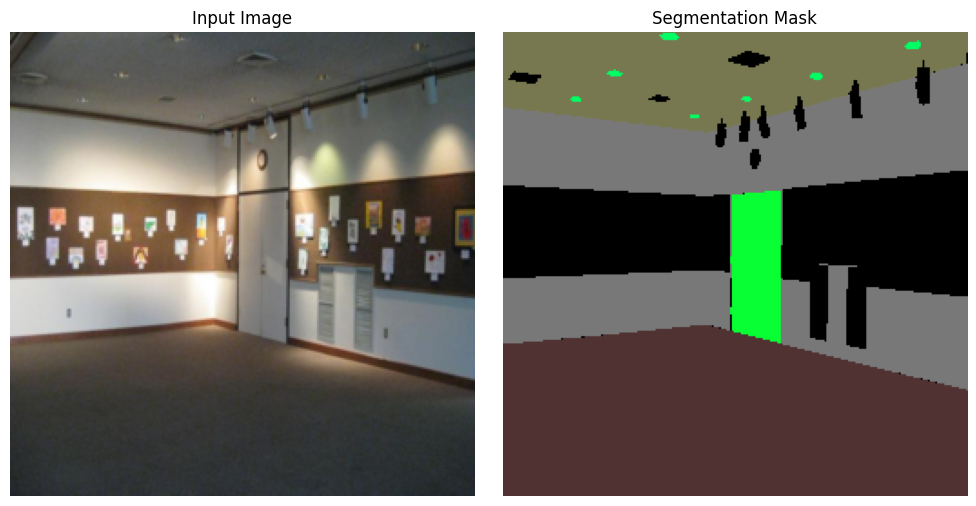

In [3]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import torch

# ADE20K 150-class color palette from MIT Scene Parsing Benchmark
ADE20K_COLORMAP = [
    (120, 120, 120), (180, 120, 120), (  6, 230, 230), ( 80,  50,  50), (  4, 200,   3),
    (120, 120,  80), (140, 140, 140), (204,   5, 255), (230, 230, 230), (  4, 250,   7),
    (224,   5, 255), (235, 255,   7), (150,   5,  61), (120, 120,  70), (  8, 255,  51),
    (255,   6,  82), (143, 255, 140), (204, 255,   4), (255,  51,   7), (204,  70,   3),
    (  0, 102, 200), ( 61, 230, 250), (255,   6,  51), ( 11, 102, 255), (255,   7,  71),
    (255,   9, 224), (  9,   7, 230), (220, 220, 220), (255,   9,  92), (112,   9, 255),
    (  8, 255, 214), (  7, 255, 224), (255, 184,   6), ( 10, 255,  71), (255,  41,  10),
    (  7, 255, 255), (224, 255,   8), (102,   8, 255), (255,  61,   6), (255, 194,   7),
    (255, 122,   8), (  0, 255,  20), (255,   8,  41), (255,   5, 153), (  6,  51, 255),
    (235,  12, 255), (160, 150,  20), (  0, 163, 255), (140, 140, 140), (250,  10,  15),
    ( 20, 255,   0), ( 31, 255,   0), (255,  31,   0), (255, 224,   0), (153, 255,   0),
    (  0,  0, 255), (255,  71,   0), (  0, 235, 255), (  0, 173, 255), ( 31,   0, 255),
    (255,  39,   0), (255,  60,   0), (255,   0, 133), (255, 218,   7), (255,   0, 110),
    (255,   0, 255), (  0, 255, 160), (255, 255,   0), (255, 255, 255), (  0,  63, 255),
    (255,  71,  15), (  0, 255, 182), (  0, 255, 255), (255, 230,   0), (255,   0, 150),
    (255,  20, 255), (255,   0, 200), (255, 255,  25), (  0, 255,  30), ( 40,   0, 255),
    (  0, 255,  50), ( 80,   0, 255), (  0, 255, 100), (120,   0, 255), (160,   0, 255),
    (200,   0, 255), (255,   0, 245), (255,   0, 210), (255,   0, 170), (255,   0, 130),
    (255,   0,  70), (255,   0,  30), (255,  40,   0), (255,  80,   0), (255, 120,   0),
    (255, 160,   0), (255, 200,   0), (255, 240,   0), (255, 255,   0), (200, 255,   0),
    (160, 255,   0), (120, 255,   0), ( 80, 255,   0), ( 40, 255,   0), (  0, 255,   0),
    (  0, 255,  40), (  0, 255,  80), (  0, 255, 120), (  0, 255, 160), (  0, 255, 200),
    (  0, 255, 240), (  0, 255, 255), (  0, 200, 255), (  0, 160, 255), (  0, 120, 255),
    (  0,  80, 255), (  0,  40, 255), (  0,   0, 255), ( 40,   0, 255), ( 80,   0, 255),
    (120,   0, 255), (160,   0, 255), (200,   0, 255), (255,   0, 255), (255,   0, 200),
    (255,   0, 160), (255,   0, 120), (255,   0,  80), (255,   0,  40), (255,   0,   0),
    (255,  40,   0), (255,  80,   0), (255, 120,   0), (255, 160,   0), (255, 200,   0),
    (255, 240,   0), (255, 255,   0)
]


def show_image_and_mask(image: torch.Tensor, mask: torch.Tensor, class_colors=None, class_labels=None):
    """
    image: Tensor of shape (3, H, W), normalized
    mask : Tensor of shape (H, W), with integer class indices
    class_colors: Optional list of RGB tuples (0-255) for mapping class indices
    class_labels: Optional list of class names corresponding to indices
    """
    # Denormalize the image for visualization (ImageNet stats)
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std  = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    image_vis = image * std + mean
    image_vis = torch.clamp(image_vis, 0, 1)

    # Create color mask if class_colors provided
    if class_colors is not None:
        mask_rgb = torch.zeros(3, *mask.shape, dtype=torch.uint8)
        for idx, color in enumerate(class_colors):
            mask_rgb[:, mask == idx] = torch.tensor(color, dtype=torch.uint8).view(3, 1)
        mask_vis = mask_rgb.permute(1, 2, 0).numpy()
    else:
        mask_vis = mask.numpy()

    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(image_vis.permute(1, 2, 0).cpu())
    axs[0].set_title("Input Image")
    axs[0].axis("off")

    if class_colors is not None:
        axs[1].imshow(mask_vis)
    else:
        im = axs[1].imshow(mask_vis, cmap="tab20", vmin=0, vmax=150)
        fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

    axs[1].set_title("Segmentation Mask")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()


# Get a sample from the dataset
image, mask = train_ds[2]

# Visualize
show_image_and_mask(image, mask, class_colors=ADE20K_COLORMAP, class_labels=None)


In [4]:
mask

tensor([[5, 5, 5,  ..., 5, 5, 5],
        [5, 5, 5,  ..., 5, 5, 5],
        [5, 5, 5,  ..., 5, 5, 5],
        ...,
        [3, 3, 3,  ..., 3, 3, 3],
        [3, 3, 3,  ..., 3, 3, 3],
        [3, 3, 3,  ..., 3, 3, 3]])


# ADE Model

## load backbone

In [5]:
import os
from oxels.models import ImageNetModel


#backbone_run_name = "last.ckpt"
#backbone_run_name = "scarlet-sky-138"
backbone_run_name = "cluster-no-contrastive-loss.ckpt"
#ckpt_dir = os.path.join("../checkpoints")
backbone_ckpt_path = os.path.join("imagenet_backbones", backbone_run_name)
#backbone_ckpt_path = os.path.join("../checkpoints",backbone_run_name)
backbone = ImageNetModel.load_from_checkpoint(backbone_ckpt_path)
print(f"Loaded model from {os.path.join("imagenet_backbones", backbone_run_name)}")
num_oxels = backbone.hparams.num_oxels

/home/bracher/Documents/Projects/oxels/.venv/lib/python3.12/site-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


Loaded model from imagenet_backbones/cluster-no-contrastive-loss.ckpt


## Pixel Classifiers

In [6]:
import torch
import torch.nn as nn
from torchmetrics.classification import Accuracy, JaccardIndex, Recall
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from oxels.models.metrics_mixin import MetricsMixin
import torch.nn.functional as F
import lightning as L


class Simple1x1Classifier(nn.Module):
    def __init__(self, in_channels: int, num_classes: int = 1, head_groups: int = 1):
        super().__init__()
        self.num_classes = num_classes
        self.linear = nn.Linear(in_channels, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 3, 1)
        x = self.linear(x)
        x = x.permute(0, 3, 1, 2)  # [B, C, H, W]
        return x

class MLPStefanClassifier(nn.Module):
    def __init__(self, in_channels: int, num_classes: int = 1):
        super().__init__()
        self.num_classes = num_classes
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, 150),
            nn.ReLU(),
            nn.Linear(150, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 3, 1)  # [B, H, W, C]
        x = self.mlp(x)
        x = x.permute(0, 3, 1, 2)  # [B, C, H, W]
        return x


class DGLinearClassifier(MetricsMixin, L.LightningModule):
    def __init__(
        self,
        backbone: nn.Module,
        head: nn.Module,
        dataset_name: str,
        train_batch_size: int,
        val_batch_size: int,
        num_oxels: int = 64,
        image_size: int = 256,
        weight_decay: float = 0.004,
        learning_rate: float = 1e-3,
        lr_pct_start: float = 0.05,
        lr_div_factor: float = 25.0,
        lr_final_div_factor: float = 1e4,
    ):
        super().__init__()
        self.save_hyperparameters(
            ignore=["backbone", "head", "dataset_name"],
        )
        self.backbone = backbone
        self.backbone.freeze()
        self.head = head
        self.dataset_name = dataset_name
        num_classes = head.num_classes
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=255)

        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes, average='micro', ignore_index=255)
        self.val_acc = Accuracy(task="multiclass", num_classes=num_classes, average='micro', ignore_index=255)
        self.test_acc = Accuracy(task="multiclass", num_classes=num_classes, average='micro', ignore_index=255)

        self.train_miou_metric = JaccardIndex(task="multiclass", num_classes=num_classes, average="macro", ignore_index=255)
        self.val_miou_metric = JaccardIndex(task="multiclass", num_classes=num_classes, average="macro", ignore_index=255)
        self.test_miou_metric = JaccardIndex(task="multiclass", num_classes=num_classes, average="macro", ignore_index=255)

        self.train_macc = Recall(task='multiclass', num_classes=num_classes, average='macro', ignore_index=255)
        self.val_macc = Recall(task='multiclass', num_classes=num_classes, average='macro', ignore_index=255)
        self.test_macc = Recall(task='multiclass', num_classes=num_classes, average='macro', ignore_index=255)

    def forward(self, x):
        oxels = self.backbone(x)
        prediction = self.head(oxels)
        return prediction

    def compute_loss(self, batch):
        images, labels = batch # Bx3xHxW,  Bx1xHxW
        logits = self(images) # bx21xhxw
        #labels = labels.to(dtype=logits.dtype).squeeze(1) # BxHxW
        #labels = labels.squeeze(1).long()  # BxHxW, convert to long for CrossEntropyLoss
        #labels = labels.to(dtype=logits.dtype)
        loss = self.loss_fn(logits, labels)
        return loss

    def compute_metrics(self, batch):
        images, labels = batch
        logits = self(images)
        B, C, H, W = logits.shape
        assert C == self.head.num_classes, f"Got {C} output channels, expected {self.head.num_classes}"
        assert labels.dtype == torch.long
        assert labels.shape == (B, H, W)

        mx = int(labels.max())
        mn = int(labels.min())
        assert mn >= 0, f"Min label {mn} < 0"
        assert mx < C or mx == 255, f"Max label {mx} out of [0,{C-1}] or 255"

        # Resize labels to match logits spatial dimensions
        #labels_resized = F.interpolate(labels.float(), size=(H, W), mode="nearest").squeeze(1).long()
        #labels = labels.squeeze(1).long()
        loss = self.loss_fn(logits, labels)

        preds = torch.argmax(logits, dim=1) # BxHxW

        # choose the right Accuracy object based on stage
        if self.trainer.training:
            acc = self.train_acc(preds, labels)
            miou = self.train_miou_metric(preds, labels)
            macc = self.train_macc(preds, labels)
        elif self.trainer.validating:
            acc = self.val_acc(preds, labels)
            miou = self.val_miou_metric(preds, labels)
            macc = self.val_macc(preds, labels)
        else:  # testing
            #raise RuntimeError("Testing is not supported in this module. Use validation metrics instead.")
            acc = self.test_acc(preds, labels)
            miou = self.test_miou_metric(preds, labels)
            macc = self.test_macc(preds, labels)

        return {
            "loss": loss,
            "accuracy": acc,
            "miou": miou,
            "macc": macc,
        }

    def configure_optimizers(self):
        lr = self.hparams.learning_rate
        wd = self.hparams.weight_decay

        # only use parameters that requires grad
        params = [p for p in self.parameters() if p.requires_grad]
        optimizer = AdamW(params, lr=lr, weight_decay=wd, betas=(0.9, 0.99))
        scheduler = OneCycleLR(
            optimizer,
            max_lr=lr,
            total_steps=self.trainer.estimated_stepping_batches,
            div_factor=self.hparams.lr_div_factor,
            final_div_factor=self.hparams.lr_final_div_factor,
            pct_start=self.hparams.lr_pct_start,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "step"},
        }

    def validation_step(self, batch, batch_idx, dataloader_idx=0):
        metrics = self.compute_metrics(batch)
        prefix = "validation/" if dataloader_idx == 0 else "validation/ood/"
        for key, value in metrics.items():
            key = f"{prefix}{key}"
            self.log(key,
                     value,
                     on_step=False,
                     on_epoch=True,
                     sync_dist=True,
                     prog_bar=(dataloader_idx == 0),  # maybe only show ID in prog bar
                     logger=True)

        return metrics["loss"]

    def train_dataloader(self):
        # Create the VOC2012 segmentation datasets
        root_dir = "datasets/ADEChallengeData2016/ADEChallengeData2016"
        images_dir = os.path.join(root_dir, "images")
        annotations_dir = os.path.join(root_dir, "annotations")

        images_train_dir = os.path.join(images_dir, "training")
        annotations_train_dir = os.path.join(annotations_dir, "training")
        train_dataset = ADE20KSegDataset(
            images_dir=images_train_dir,
            masks_dir=annotations_train_dir,
        )
        return DataLoader(
            train_dataset,
            batch_size=self.hparams.train_batch_size,
            shuffle=True,
            pin_memory=True,
            num_workers=len(os.sched_getaffinity(0)),
            drop_last=True,
        )

    def val_dataloader(self):
        root_dir = "datasets/ADEChallengeData2016/ADEChallengeData2016"
        images_dir = os.path.join(root_dir, "images")
        annotations_dir = os.path.join(root_dir, "annotations")

        images_val_dir = os.path.join(images_dir, "validation")
        annotations_val_dir = os.path.join(annotations_dir, "validation")
        val_dataset = ADE20KSegDataset(
            images_dir=images_val_dir,
            masks_dir=annotations_val_dir,
        )
        return DataLoader(val_dataset, batch_size=self.hparams.val_batch_size, shuffle=False,  num_workers=len(os.sched_getaffinity(0)), drop_last=False)

# Training

## Setup

In [10]:
import torch
from lightning.pytorch import callbacks
from lightning.pytorch.loggers import WandbLogger
from torchmetrics import Accuracy
import lightning as L
from lightning.pytorch.loggers import WandbLogger

import wandb
from oxels.callbacks import ShowOxels


torch.cuda.empty_cache()
torch.set_float32_matmul_precision("medium")

print("Device Count:", torch.cuda.device_count())
project = "ADE20k-testing"
num_classes = 150
total_steps = 100_000
image_size = 256
num_nodes = 1
num_devices = 1
train_batch_size = 64
val_batch_size = 128
learning_rate = 5e-4
lr_pct_start = 0.05
weight_decay = 1e-6

model_config = dict(
    num_oxels=num_oxels,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    lr_pct_start=lr_pct_start,
    lr_div_factor=25.0,
    lr_final_div_factor=1e3,
    train_batch_size=train_batch_size,
    val_batch_size=val_batch_size,
    image_size=image_size,
)

trainer_config = dict(
    gradient_clip_val=3.0,
    gradient_clip_algorithm="value",
    max_steps=total_steps,
    accelerator="gpu",
    strategy="auto",
    devices=num_devices,
    precision="16-mixed",
    num_nodes=num_nodes,
)

model = DGLinearClassifier(
    backbone=backbone,
    head=MLPStefanClassifier(num_oxels, num_classes),
    dataset_name="ADE20k",
    train_batch_size=train_batch_size,
    val_batch_size=val_batch_size,
    num_oxels=num_oxels,
    image_size=image_size,
    weight_decay=weight_decay,
    learning_rate=learning_rate,
    lr_pct_start=lr_pct_start,
    lr_div_factor=25.0,
    lr_final_div_factor=1e4)

with torch.device("cpu"):
    train_images = [model.train_dataloader().dataset[i][0] for i in range(4)]
    train_images = torch.stack(train_images)
    validation_images = [model.val_dataloader().dataset[i][0] for i in range(4)]
    validation_images = torch.stack(validation_images)
    train_labels = [model.train_dataloader().dataset[i][1] for i in range(4)]
    train_labels = torch.stack(train_labels)
    validation_labels = [model.val_dataloader().dataset[i][1] for i in range(4)]
    validation_labels = torch.stack(validation_labels)

num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters: ", num_parameters)
config = model_config | trainer_config

Device Count: 1
Total parameters:  37550


## Init WandB and Start Training

In [ ]:
from oxels.callbacks import ShowSegmentationWandb

run = wandb.init(
    entity="kl_divergence-rensselaer-polytechnic-institute",
    project=project,
    config=config,
    dir="wandb_results"
)

logger = WandbLogger(
    experiment=run,
)

wandb.summary["num_parameters"] = num_parameters
#wandb.summary["backbone_run_id"] = "synthetic_VOCS_1.0"
#wandb.summary["backbone_run_name"] = backbone_run_name
wandb.summary["model_type"] = "MLPClassifier"
run_name = wandb.run.name
run_id = wandb.run.id
print(f"name: {run_name} \t run id:{run_id}")

ckpt_dir = os.path.join("lightning_logs", str(run_name))
# make sure the directory exists
os.makedirs(ckpt_dir, exist_ok=True)
with open(os.path.join(ckpt_dir, "wandb_run_id.txt"), "w") as f:
    f.write(run_id)
trainer = L.Trainer(
    **trainer_config,
    callbacks=[
        callbacks.LearningRateMonitor(logging_interval="step"),
        callbacks.ModelCheckpoint(
            dirpath=ckpt_dir,
            monitor="validation/loss",
            mode="min",
            save_top_k=1,
            filename="best_model",
            save_last=True,
        ),
        ShowSegmentationWandb(images=train_images, labels=train_labels, every_n_epochs=10, caption="Train Segmentations"),
        ShowSegmentationWandb(images=validation_images, labels=validation_labels, every_n_epochs=10, caption="Validation Segmentations"),
    ],
    logger=logger,
)

try:
    trainer.fit(model)
    result = trainer.callback_metrics["validation/loss"]
    wandb.summary["result"] = result

finally:
    # clean up
    wandb.finish()

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/bracher/Documents/Projects/oxels/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/bracher/Documents/Projects/oxels/notebooks/lightning_logs/amber-star-14 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name              | Type                   | Params | Mode 
----------------------------------------------------------------------
0  | backbone          | ImageNetModel          | 36.2 M | eval 
1  | head              | MLPStefanClassifier    | 37.6 K | train
2  | loss_fn           | CrossEntropyLoss       | 0      | train
3  | train_acc         | MulticlassAccuracy     | 0      | train
4  | val_acc           | MulticlassAccuracy     | 0      | train
5  | test_acc          | MulticlassAccuracy     | 0      | train
6  | train_miou_metr

name: amber-star-14 	 run id:0dv6sn46


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

In [9]:
torch.cuda.empty_cache()